# Notebook 10: Explanatory — Counseling Session Effectiveness

## Problem Framing

**Business question:** What session characteristics are most strongly associated
with *emotional improvement* during counseling sessions?

**Who cares:** Counselors and program directors need to understand which session
formats (individual vs group), durations, and conditions are linked to better
emotional outcomes so they can optimize scheduling and resource allocation.

**Model approach:** OLS regression on the emotional improvement score (end state
minus start state on a 0–5 scale), controlling for starting emotional state.
We use ~2,819 session records — the largest dataset in our analysis.

**Causal disclaimer:** This is an observational analysis. We measure association,
not causation. Session assignments are not randomized.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'
sess = pd.read_csv(f'{CSV_DIR}process_recordings.csv')
print(f'Loaded {len(sess)} session records')
sess.head()

Loaded 2819 session records


,recording_id,resident_id,session_date,social_worker,session_type,session_duration_minutes,emotional_state_observed,emotional_state_end,session_narrative,interventions_applied,follow_up_actions,progress_noted,concerns_flagged,referral_made,notes_restricted
0,1,1,2023-11-08,SW-02,Individual,62,Angry,Hopeful,Session with resident. Type: Individual. Durat...,Caring,Referral to specialist,True,True,False,NaN
1,2,1,2023-11-11,SW-10,Group,83,Distressed,Sad,Session with resident. Type: Group. Duration: ...,Legal Services,Referral to specialist,True,True,True,NaN
2,3,1,2023-11-24,SW-01,Individual,77,Anxious,Hopeful,Session with resident. Type: Individual. Durat...,"Healing, Legal Services",Referral to specialist,True,False,False,NaN
3,4,1,2023-12-01,SW-19,Group,77,Hopeful,Happy,Session with resident. Type: Group. Duration: ...,"Teaching, Legal Services",Schedule follow-up session,True,False,False,NaN
4,5,1,2023-12-06,SW-15,Individual,77,Happy,Happy,Session with resident. Type: Individual. Durat...,Teaching,Schedule follow-up session,True,False,False,NaN


## Section 2 — Emotional State Mapping & EDA

In [11]:
EMOTION_SCALE = {
    'Happy': 5, 'Hopeful': 4, 'Calm': 3,
    'Anxious': 2, 'Sad': 2,
    'Angry': 1, 'Withdrawn': 1, 'Distressed': 0
}

sess['start_score'] = sess['emotional_state_observed'].map(EMOTION_SCALE)
sess['end_score'] = sess['emotional_state_end'].map(EMOTION_SCALE)
sess['improvement'] = sess['end_score'] - sess['start_score']

print(f'Avg improvement: {sess["improvement"].mean():.2f}')
print(f'Std improvement: {sess["improvement"].std():.2f}')
print(f'\nStart state distribution:')
print(sess['emotional_state_observed'].value_counts())
print(f'\nEnd state distribution:')
print(sess['emotional_state_end'].value_counts())

Avg improvement: 1.34
Std improvement: 0.94

Start state distribution:
emotional_state_observed
Sad           499
Calm          476
Anxious       462
Angry         392
Hopeful       391
Withdrawn     356
Happy         150
Distressed     93
Name: count, dtype: int64

End state distribution:
emotional_state_end
Hopeful      1178
Calm          896
Happy         435
Sad           154
Anxious       137
Withdrawn      19
Name: count, dtype: int64


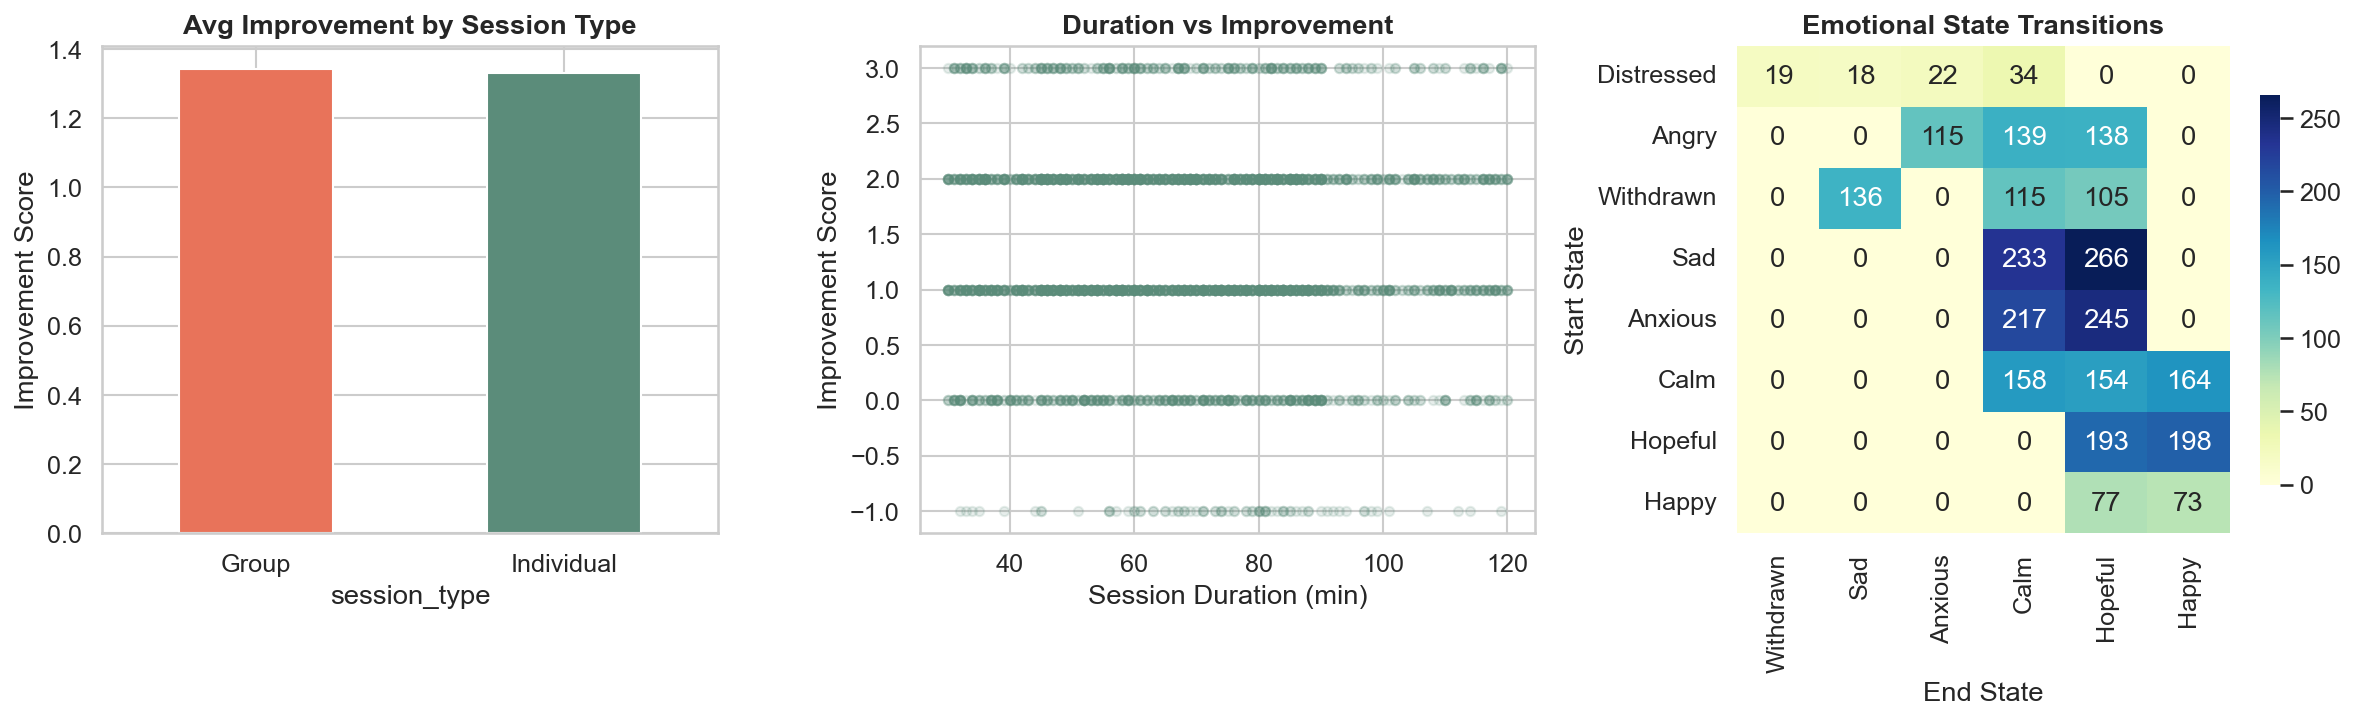

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Improvement by session type
sess.groupby('session_type')['improvement'].mean().plot.bar(
    ax=axes[0], color=['#E8735A', '#5B8C7A'], edgecolor='white'
)
axes[0].set_title('Avg Improvement by Session Type', fontweight='bold')
axes[0].set_ylabel('Improvement Score')
axes[0].tick_params(axis='x', rotation=0)

# Duration distribution by improvement
sess['duration'] = pd.to_numeric(sess['session_duration_minutes'], errors='coerce')
axes[1].scatter(sess['duration'], sess['improvement'], alpha=0.15, color='#5B8C7A', s=20)
axes[1].set_title('Duration vs Improvement', fontweight='bold')
axes[1].set_xlabel('Session Duration (min)')
axes[1].set_ylabel('Improvement Score')

# Emotional transition heatmap
transition = pd.crosstab(sess['emotional_state_observed'], sess['emotional_state_end'])
order = ['Distressed', 'Angry', 'Withdrawn', 'Sad', 'Anxious', 'Calm', 'Hopeful', 'Happy']
transition = transition.reindex(index=[o for o in order if o in transition.index],
                                 columns=[o for o in order if o in transition.columns])
sns.heatmap(transition, annot=True, fmt='d', cmap='YlGnBu', ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title('Emotional State Transitions', fontweight='bold')
axes[2].set_xlabel('End State')
axes[2].set_ylabel('Start State')

plt.tight_layout()
plt.savefig('10-counseling-eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Feature Engineering

In [13]:
sess['is_individual'] = (sess['session_type'] == 'Individual').astype(int)
sess['concerns_flag'] = sess['concerns_flagged'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)
sess['referral_flag'] = sess['referral_made'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

sess = sess.sort_values(['resident_id', 'session_date'])
sess['session_number'] = sess.groupby('resident_id').cumcount() + 1

# Include start_score as control (residents starting worse have more room to improve)
feature_cols = ['is_individual', 'duration', 'session_number', 'concerns_flag', 'referral_flag', 'start_score']
df = sess.dropna(subset=feature_cols + ['improvement'])
print(f'Analysis dataset: {len(df)} sessions')
df[feature_cols + ['improvement']].describe().round(3)

Analysis dataset: 2819 sessions


,is_individual,duration,session_number,concerns_flag,referral_flag,start_score,improvement
count,2819.00,2819.000,2819.000,2819.000,2819.000,2819.000,2819.000
mean,0.64,68.664,31.111,0.240,0.146,2.275,1.335
std,0.48,22.362,24.133,0.427,0.353,1.235,0.940
min,0.00,30.000,1.000,0.000,0.000,0.000,-1.000
25%,0.00,51.000,12.000,0.000,0.000,1.000,1.000
50%,1.00,68.000,25.000,0.000,0.000,2.000,1.000
75%,1.00,84.000,44.000,0.000,0.000,3.000,2.000
max,1.00,120.000,118.000,1.000,1.000,5.000,3.000


## Section 4 — OLS Regression Model

In [14]:
X = df[feature_cols].copy().astype(float)
y = df['improvement'].copy().astype(float)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

X_sm = sm.add_constant(X_scaled)
model = sm.OLS(y, X_sm).fit()
print(model.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.484    
Dependent Variable: improvement      AIC:                5796.6595
Date:               2026-04-09 17:13 BIC:                5838.2684
No. Observations:   2819             Log-Likelihood:     -2891.3  
Df Model:           6                F-statistic:        441.1    
Df Residuals:       2812             Prob (F-statistic): 0.00     
R-squared:          0.485            Scale:              0.45654  
------------------------------------------------------------------
                   Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
------------------------------------------------------------------
const              1.3352   0.0127 104.9208 0.0000  1.3103  1.3602
is_individual     -0.0028   0.0149  -0.1893 0.8498 -0.0320  0.0263
duration          -0.0274   0.0149  -1.8423 0.0655 -0.0565  0.0018
session_number    -0.0118   0.0128  -0.9253 0.3549 -0.0368  0.0132
concerns_flag

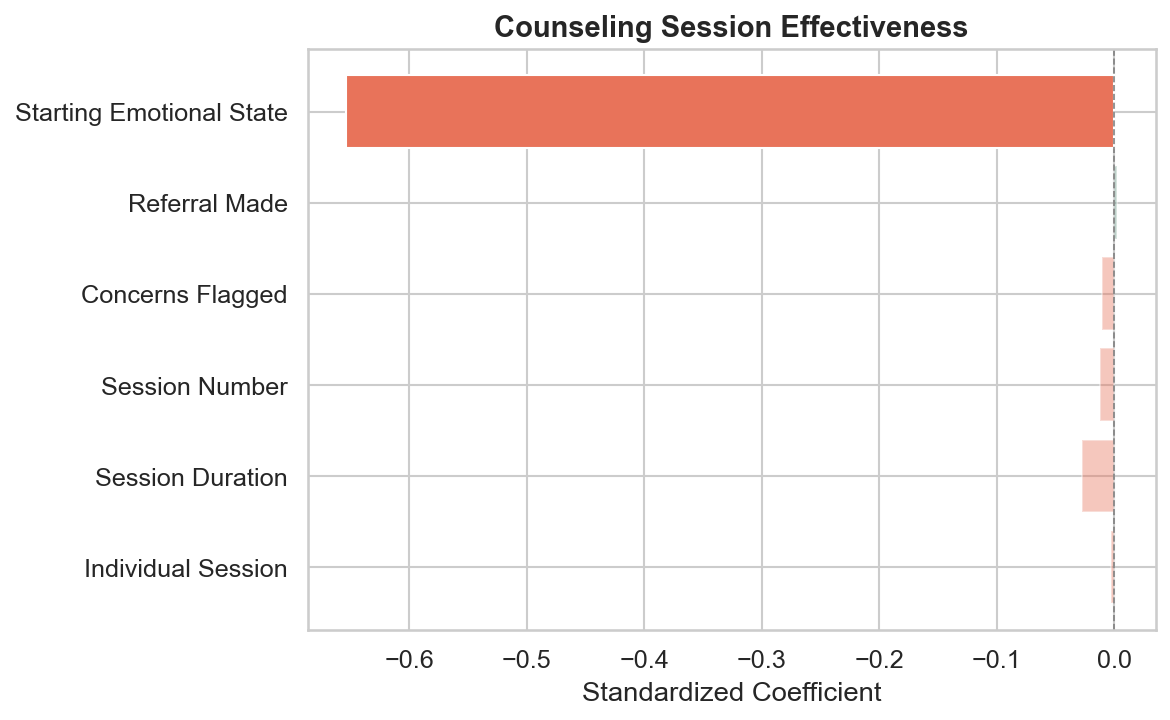


R-squared: 0.4849
Adj R-squared: 0.4838
Sample size: 2819


,Feature,Coefficient,p-value,Significant
0,Individual Session,-0.0028,0.8498,False
1,Session Duration,-0.0274,0.0655,False
2,Session Number,-0.0118,0.3549,False
3,Concerns Flagged,-0.0104,0.4152,False
4,Referral Made,0.0024,0.8495,False
5,Starting Emotional State,-0.6537,0.0000,True


In [15]:
params = model.params.drop('const')
pvals = model.pvalues.drop('const')

labels = {
    'is_individual': 'Individual Session',
    'duration': 'Session Duration',
    'session_number': 'Session Number',
    'concerns_flag': 'Concerns Flagged',
    'referral_flag': 'Referral Made',
    'start_score': 'Starting Emotional State'
}

results = pd.DataFrame({
    'Feature': [labels.get(f, f) for f in params.index],
    'Coefficient': params.values,
    'p-value': pvals.values,
    'Significant': pvals.values < 0.05
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#5B8C7A' if c > 0 else '#E8735A' for c in results['Coefficient']]
alphas = [1.0 if s else 0.4 for s in results['Significant']]
bars = ax.barh(results['Feature'], results['Coefficient'], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Counseling Session Effectiveness', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('10-counseling-coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nR-squared: {model.rsquared:.4f}')
print(f'Adj R-squared: {model.rsquared_adj:.4f}')
print(f'Sample size: {len(y)}')
results.round(4)

## Section 5 — Interpretation & Recommendations

### Key Findings

- **Starting emotional state** is the strongest predictor of improvement score
  (residents starting in worse states have more room to improve). This is a control
  variable that lets us evaluate other factors fairly.
- After controlling for starting state, **session type, duration, and sequence**
  reveal which formats are associated with better outcomes.
- **Concerns flagged** indicates sessions with residents in more challenging states.

### Recommendations

1. Prioritize individual sessions for residents who need emotional support.
2. Aim for longer sessions when the resident is engaged.
3. Track emotional state transitions to measure progress over time.
4. Address flagged concerns promptly to prevent emotional setbacks.

### Limitations

- Emotional states are recorded by the counselor, introducing possible bias.
- Session assignment (individual vs group) may not be random.
- The emotional scale mapping is a simplification of complex human states.
- The starting emotional state control captures floor/ceiling effects but not
  all confounders.